# CUI revision

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF

In [2]:
lati1,lati2=-4,-17
mask_km = 111

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [4]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

### Brief revision to CUI

In [5]:
SST = xr.open_dataset('../SST.nc').compute()
SST= SST.where(SST.SST!=0,np.nan)
SST

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SST      (time, lat, lon) float32 564MB 20.19 20.18 20.24 ... nan nan nan

In [6]:
# 1. Define the utility function once
def get_custom_band(ds,variable, inner_km, outer_km):
    """Returns the interval between two distances."""
    inner = coastal_band_mask(ds,var='SST' ,target_width_km=inner_km)
    outer = coastal_band_mask(ds,var='SST' ,target_width_km=outer_km)
    return outer & (~inner)

In [7]:
# 2. Use it in your main script
# Now you don't need to manually define 'mask_500' and 'mask_750' 
# just to calculate the difference.
inshore_mask = coastal_band_mask(SST,'SST', target_width_km=mask_km)
offshore_band = get_custom_band(SST,'SST', 500, 750)

# 3. Clean conversion to NaN
# You can use .where(mask) directly, which creates the NaN values automatically
inshore_final = inshore_mask.where(inshore_mask)
offshore_final = offshore_band.where(offshore_band)

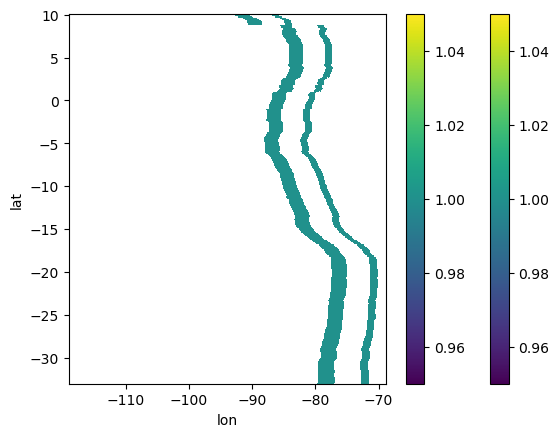

In [8]:
inshore_final.plot()
offshore_final.plot()

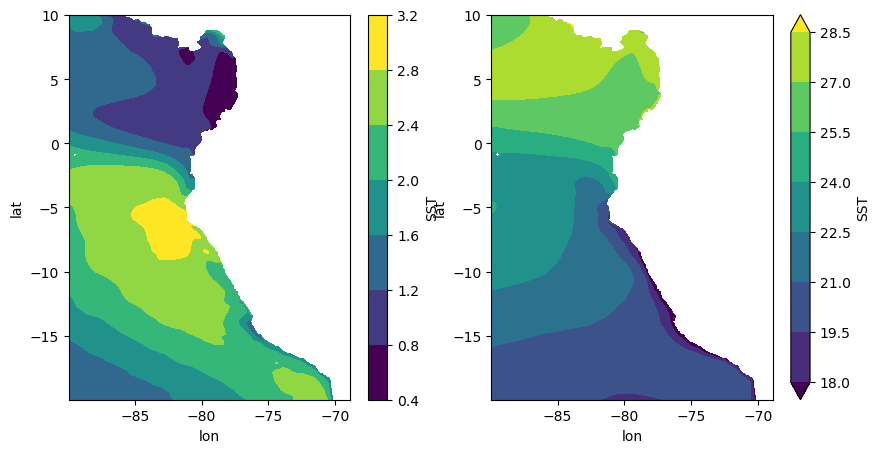

In [9]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
SST.SST.std('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[0])
SST.SST.mean('time').sel(lon=slice(-90,None),lat=slice(-20,None)).plot.contourf(robust=True,ax=ax[1])

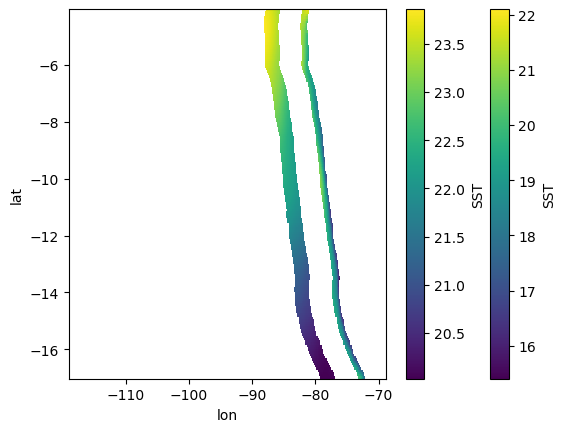

In [10]:
SST_in = SST.where(inshore_mask).sel(lat=slice(lati2,lati1))
SST_off = SST.where(offshore_band).sel(lat=slice(lati2,lati1))

SST_in.mean('time').SST.plot()
SST_off.mean('time').SST.plot()

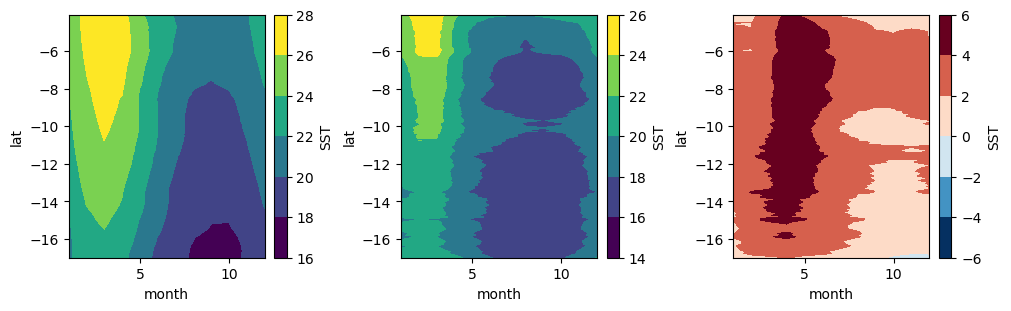

In [11]:
fig,ax = plt.subplots(1,3,figsize=(10,3), constrained_layout=True)
seasonality(SST_off).mean(dim='lon').SST.plot.contourf(x='month',ax=ax[0])
seasonality(SST_in).mean(dim='lon').SST.plot.contourf(x='month',ax=ax[1])
(seasonality(SST_off).mean('lon') - seasonality(SST_in).mean('lon')).SST.plot.contourf(x='month',ax=ax[2])

* Still didn't work

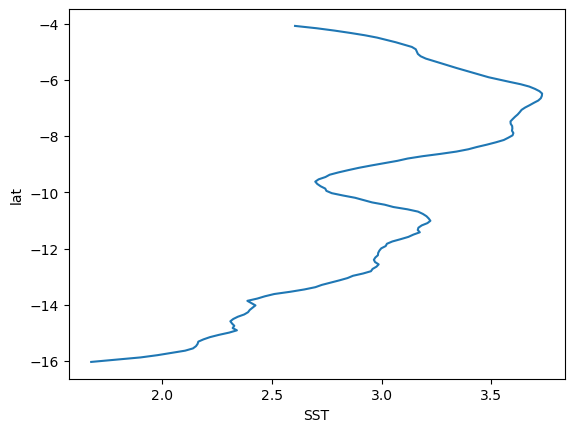

In [12]:
CUI = (SST_off.mean('lon') - SST_in.mean('lon'))
CUI.SST.mean('time').rolling(lat=13).mean().sel(lat=slice(lati2,lati1)).plot(y='lat')

In [13]:
CUI = CUI.SST.rename('CUI_cc')
# CUI.to_dataset().to_netcdf('CUI.nc')

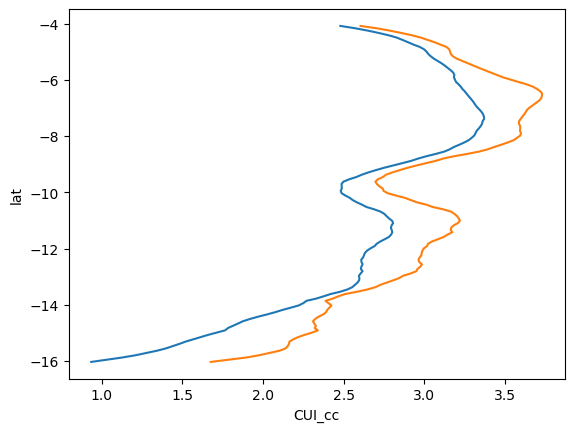

In [14]:
xr.open_dataset('../CUI_oldmask.nc').compute().CUI_cc.mean('time').rolling(lat=13).mean().plot(y='lat')
CUI.mean('time').rolling(lat=13).mean().sel(lat=slice(lati2,lati1)).plot(y='lat')

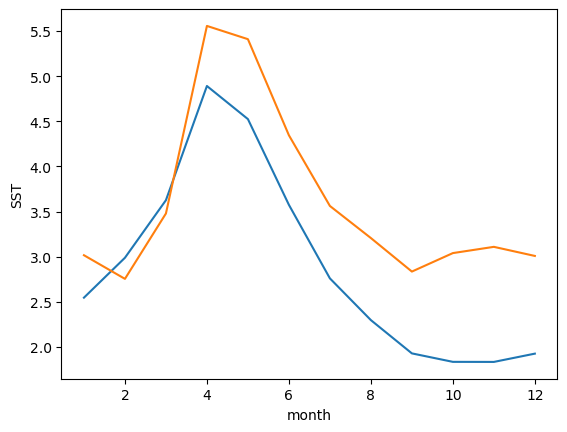

In [15]:
seasonality(CUI.mean('lat')).plot()
(seasonality(SST_off).mean('lon') - seasonality(SST_in).mean('lon')).SST.sel(lat=slice(-8,-6)).mean('lat').plot()

In [16]:
CUI = CUI.assign_coords(
    year=CUI.time.dt.year,
    month=CUI.time.dt.month
)
CUI_ = CUI.set_index(time=['year', 'month']).unstack('time')


In [17]:
CUI_

<xarray.DataArray 'CUI_cc' (lat: 159, year: 36, month: 12)> Size: 275kB
array([[[ 1.0548038 ,  0.6062412 ,  1.1805325 , ..., -0.7416382 ,
         -1.3137131 , -0.76571655],
        [ 0.20132256,  1.6641712 ,  2.261818  , ..., -0.24059868,
          0.61810684,  0.3659668 ],
        [ 0.49744034,  1.8276138 ,  1.2967911 , ..., -0.07928658,
         -0.8236027 , -0.8846264 ],
        ...,
        [ 1.8604431 ,  1.9937439 ,  3.0434952 , ..., -0.6749821 ,
         -0.91542244, -0.5982437 ],
        [ 0.532814  ,  0.22397995,  0.44083786, ..., -0.4726715 ,
         -0.10066795,  0.7725735 ],
        [ 1.0647144 ,  1.3969402 ,  0.83696556, ..., -0.883255  ,
         -0.06668091, -0.60139465]],

       [[ 1.5487652 ,  1.0559502 ,  1.4305344 , ..., -0.64951324,
         -1.2672596 , -0.6076317 ],
        [ 0.59432983,  1.932869  ,  2.3681679 , ...,  0.01203537,
          0.840044  ,  0.62413216],
        [ 0.59456444,  2.0044327 ,  1.4569569 , ...,  0.03660583,
         -0.6794014 , -0.62251854],
...
        [ 0.8520546 ,  0.75200653,  2.4813614 , ...,  0.95687294,
          0.26550674,  1.0704823 ],
        [ 0.928957  ,  1.7321014 ,  2.9715672 , ...,  1.2430553 ,
          0.4246502 ,  2.1202145 ],
        [ 2.7440395 ,  1.0888882 ,  1.2980652 , ...,  0.527668  ,
          0.2808628 ,  0.9383774 ]],

       [[ 0.7506466 ,  2.115099  ,  2.8325367 , ..., -0.01194954,
          0.9121704 ,  2.3890495 ],
        [ 1.5238228 ,  2.1518078 ,  1.7868729 , ...,  0.2679062 ,
          1.272995  ,  0.30215073],
        [ 0.9265938 ,  1.5394478 ,  2.8623676 , ...,  0.6377201 ,
         -0.48755455, -0.06650543],
        ...,
        [ 0.7114353 ,  0.69519997,  2.3558426 , ...,  0.5674343 ,
          0.07945824,  0.9701042 ],
        [ 0.88420296,  1.5069275 ,  2.7475014 , ...,  0.97084427,
          0.24918175,  1.9644203 ],
        [ 2.6066399 ,  1.1000042 ,  1.3991165 , ...,  0.3710842 ,
          0.25012589,  0.8146515 ]]], dtype=float32)
Coordinates:
  * year     (year) int64 288B 1980 1981 1982 1983 1984 ... 2012 2013 2014 2015
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079

Text(0.5, 1.0, '$SST_{index}$')

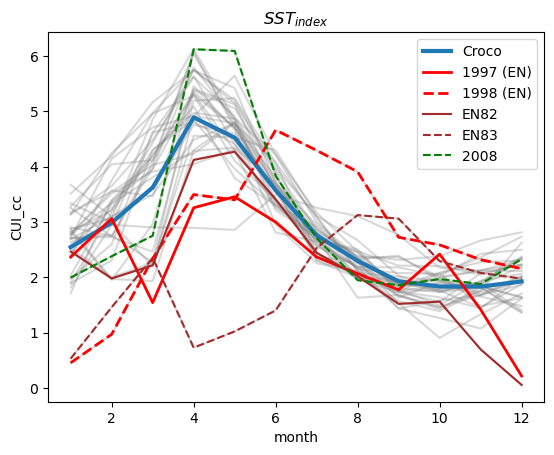

In [18]:
data = (CUI_).mean(dim=('lat'))

data.plot(
    x='month', 
    hue='year',      # This keeps the lines separated by year
    add_legend=False, # This hides the legend
    color='gray',
    alpha=0.3# This may be overridden by the hue cycle, see note below
)

seasonality(CUI).mean(dim=('lat')).rename('C').plot(label='Croco',linewidth=3)
# 3. Plot highlighted years (Red for 1997-1998)
# 1. Plot 1997 as a solid line
data.sel(year=1997).plot(
    x='month', 
    color='red', 
    linestyle='-', 
    linewidth=2, 
    label='1997 (EN)'
)

# 2. Plot 1998 as a dashed line
data.sel(year=1998).plot(
    x='month', 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label='1998 (EN)'
)
# 4. Plot highlighted years (Brown for 1982-1983)
# Plot 1982 (Red, Dashed)
data.sel(year=1982).plot(x='month', color='brown', linestyle='-', label='EN82')

# Plot 1983 (Brown, Dotted)
data.sel(year=1983).plot(x='month', color='brown', linestyle='--', label='EN83')

data.sel(year=2008).plot(x='month', color='green', linestyle='--', label='2008')

plt.legend()
plt.title('$SST_{index}$')

Text(0.5, 1.0, '$SST_{index}$ 6S-8S')

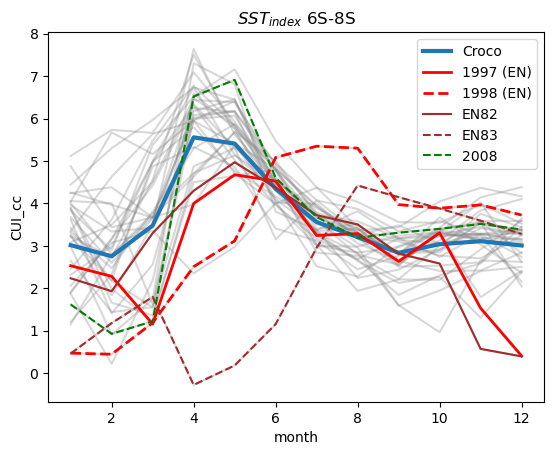

In [19]:
data = (CUI_).sel(lat=slice(-8,-6)).mean(dim=('lat'))

data.plot(
    x='month', 
    hue='year',      # This keeps the lines separated by year
    add_legend=False, # This hides the legend
    color='gray',
    alpha=0.3# This may be overridden by the hue cycle, see note below
)

seasonality(CUI).sel(lat=slice(-8,-6)).mean(dim=('lat')).rename('C').plot(label='Croco',linewidth=3)
# 3. Plot highlighted years (Red for 1997-1998)
# 1. Plot 1997 as a solid line
data.sel(year=1997).plot(
    x='month', 
    color='red', 
    linestyle='-', 
    linewidth=2, 
    label='1997 (EN)'
)

# 2. Plot 1998 as a dashed line
data.sel(year=1998).plot(
    x='month', 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label='1998 (EN)'
)
# 4. Plot highlighted years (Brown for 1982-1983)
# Plot 1982 (Red, Dashed)
data.sel(year=1982).plot(x='month', color='brown', linestyle='-', label='EN82')

# Plot 1983 (Brown, Dotted)
data.sel(year=1983).plot(x='month', color='brown', linestyle='--', label='EN83')

data.sel(year=2008).plot(x='month', color='green', linestyle='--', label='2008')

plt.legend()
plt.title('$SST_{index}$ 6S-8S')

## Temperature

In [20]:
temp = xr.open_dataset('../../Temp.nc').compute()
temp

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 432, depth: 21, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * depth    (depth) int64 168B 5 10 20 30 40 50 60 ... 200 220 240 260 280 300
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    temp     (time, depth, lat, lon) float32 12GB 20.19 20.18 20.24 ... nan nan

In [21]:
SST_in = temp.where(inshore_mask).sel(lat=slice(lati2,lati1))
SST_off = temp.where(offshore_band).sel(lat=slice(lati2,lati1))

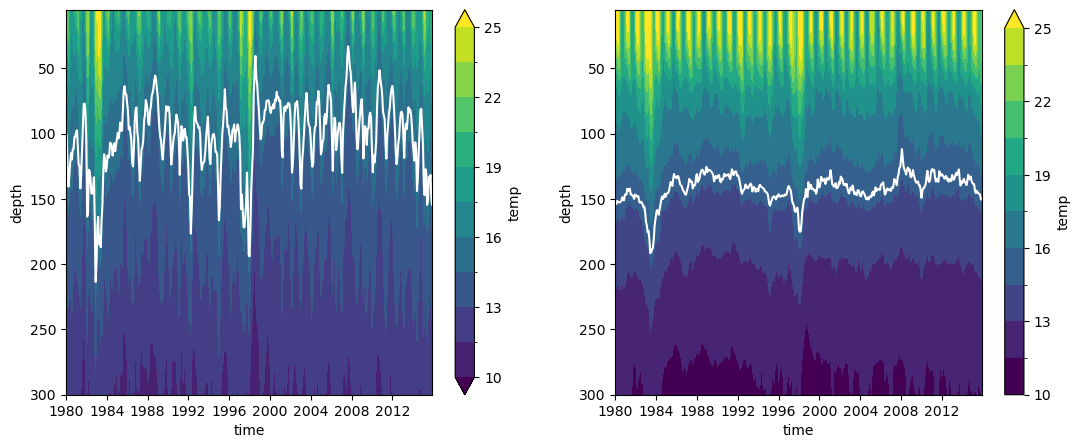

In [22]:
fig,ax = plt.subplots(1,2,figsize=(13,5))
SST_in.mean(dim=('lon','lat')).temp.plot.contourf(x='time',ax=ax[0],vmin=10,vmax=25,levels=11)
SST_in.mean(dim=('lon','lat')).temp.plot.contour(x='time',levels=[15],colors='white',ax=ax[0])

SST_off.mean(dim=('lon','lat')).temp.plot.contourf(x='time',ax=ax[1],vmin=10,vmax=25,levels=11)
SST_off.mean(dim=('lon','lat')).temp.plot.contour(x='time',levels=[15],colors='white',ax=ax[1])

ax[0].invert_yaxis()
ax[1].invert_yaxis()

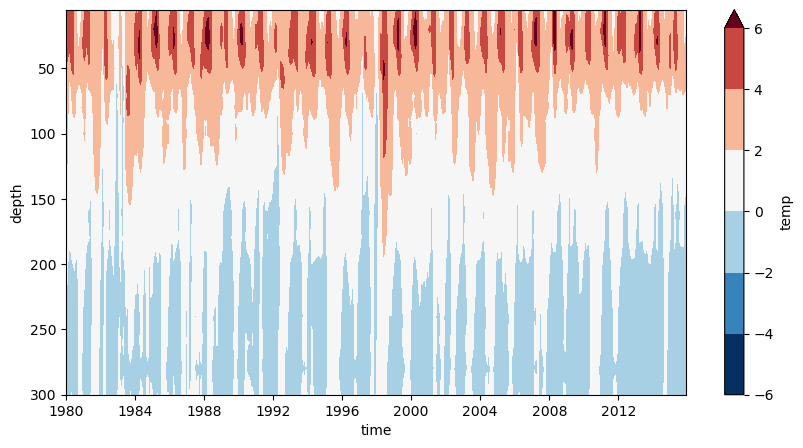

In [23]:
fig, ax = plt.subplots(figsize=(10,5))

(SST_off.mean(dim=('lon','lat')) 
 - SST_in.mean(dim=('lon','lat'))
).temp.plot.contourf(
    x='time',
    robust=True,
    ax=ax
)

ax.invert_yaxis()

In [24]:
tt = (SST_off.mean(dim=('lon','lat')) 
 - SST_in.mean(dim=('lon','lat'))
)

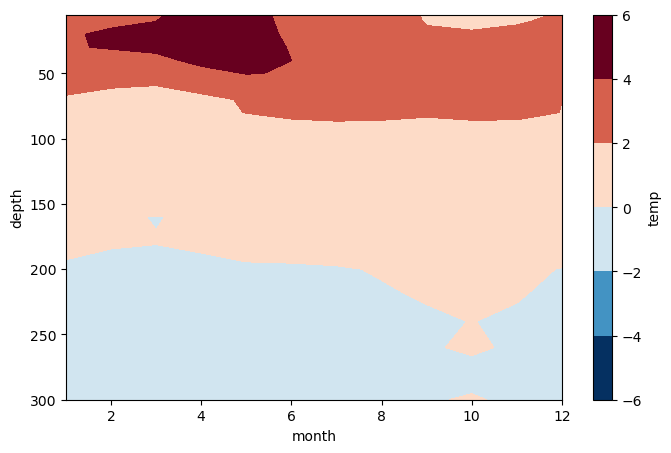

In [25]:
fig, ax = plt.subplots(figsize=(8,5))

seasonality(tt).temp.plot.contourf(
    x='month',
    robust=True,
    ax=ax
)

ax.invert_yaxis()

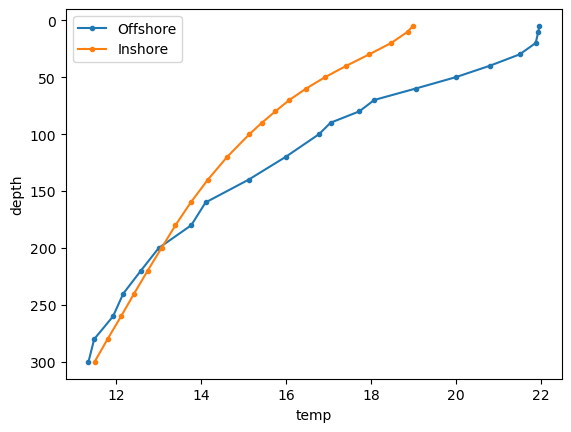

In [26]:
SST_off.mean(dim=('lon','lat','time')).temp.plot(y='depth',marker='.',label='Offshore')
SST_in.mean(dim=('lon','lat','time')).temp.plot(y='depth',marker='.',label='Inshore')
plt.gca().invert_yaxis()
plt.legend()

In [27]:
def compute_isotherm(temp_all, iso_temp=15.0):
    """
    Compute the depth of a given isotherm by linear interpolation.
    Returns NaN where the isotherm is not found (too shallow or too deep).
    
    Parameters
    ----------
    temp_all : xr.Dataset with temp (time, depth, lat, lon)
    iso_temp : target isotherm temperature in °C
    """
    temp = temp_all['temp']                        # (time, depth, lat, lon)
    depths = temp_all['depth'].values.astype(float)  # (depth,)
    
    nt = len(temp_all['time'])
    nlat = len(temp_all['lat'])
    nlon = len(temp_all['lon'])
    
    iso_depth = np.full((nt, nlat, nlon), np.nan, dtype=np.float32)
    
    temp_np = temp.values   # (time, depth, lat, lon)
    
    for t in range(nt):
        for k in range(len(depths) - 1):
            T_upper = temp_np[t, k,   :, :]   # shallower level
            T_lower = temp_np[t, k+1, :, :]   # deeper level
            z_upper = depths[k]
            z_lower = depths[k+1]
            
            # Find where isotherm is between these two levels
            # In upwelling regions temp decreases with depth, so T_upper > iso > T_lower
            mask = (
                (T_upper >= iso_temp) & (T_lower < iso_temp) &
                np.isfinite(T_upper) & np.isfinite(T_lower) &
                np.isnan(iso_depth[t])   # only fill where not already found
            )
            
            # Linear interpolation between the two levels
            frac = (iso_temp - T_upper) / (T_lower - T_upper)
            interp = z_upper + frac * (z_lower - z_upper)
            iso_depth[t][mask] = interp[mask]
    
    return xr.DataArray(
        iso_depth,
        dims=['time', 'lat', 'lon'],
        coords={
            'time': temp_all['time'],
            'lat':  temp_all['lat'],
            'lon':  temp_all['lon'],
        },
        attrs={'long_name': f'Depth of {iso_temp}°C isotherm', 'units': 'm'}
    )

In [28]:
# --- Run ---
iso15 = compute_isotherm(temp, iso_temp=15.0)
print(iso15)

/tmp/ipykernel_1298029/1350328158.py:38: RuntimeWarning: divide by zero encountered in divide
  frac = (iso_temp - T_upper) / (T_lower - T_upper)
/tmp/ipykernel_1298029/1350328158.py:38: RuntimeWarning: invalid value encountered in divide
  frac = (iso_temp - T_upper) / (T_lower - T_upper)


<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 564MB
array([[[104.55911 , 103.625595, 105.02692 , ...,        nan,
                nan,        nan],
        [105.43436 , 104.60697 , 105.01067 , ...,        nan,
                nan,        nan],
        [107.82733 , 106.892136, 106.767235, ...,        nan,
                nan,        nan],
        ...,
        [115.827095, 118.23557 , 117.16278 , ...,        nan,
                nan,        nan],
        [114.281204, 118.07152 , 117.1447  , ...,        nan,
                nan,        nan],
        [114.73541 , 115.14713 , 114.56314 , ...,        nan,
                nan,        nan]],

       [[185.11801 , 184.77267 , 184.74509 , ...,        nan,
                nan,        nan],
        [185.4561  , 184.86597 , 184.50377 , ...,        nan,
                nan,        nan],
        [186.17114 , 185.1406  , 184.1356  , ...,        nan,
                nan,        nan],
...
        [121.18779 , 123.96716 , 123.74413 , ...,     

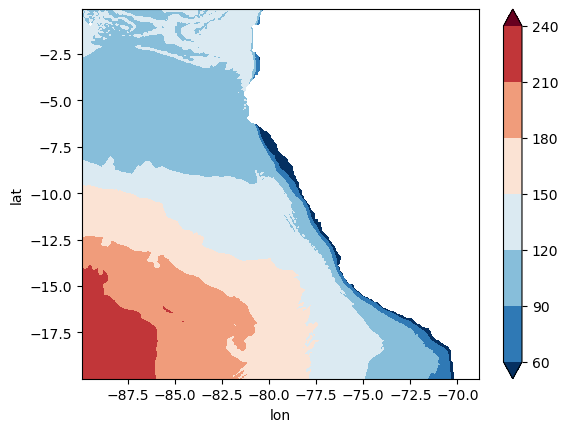

In [29]:
iso15.sel(lat=slice(-20,0),lon=slice(-90,None)).mean('time').plot.contourf(cmap='RdBu_r',robust=True)

In [34]:
def anomalies(da, dim='time', window=13):
    # Monthly climatology
    clim = da.groupby(f'{dim}.month').mean(dim)
    # Remove climatology
    anom = da.groupby(f'{dim}.month') - clim
    # Running mean
    smooth = (
        anom
        .rolling({dim: window}, center=True, min_periods=1)
        .mean()
    )
    return smooth

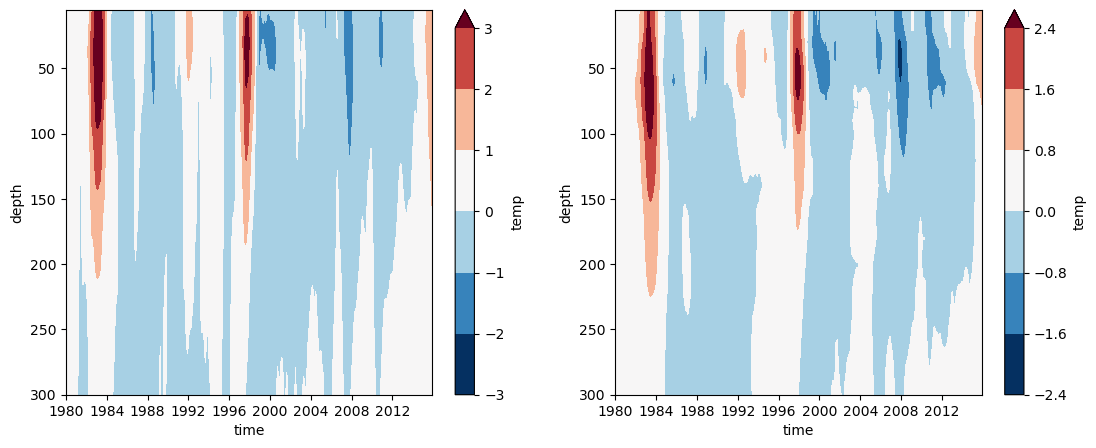

In [40]:
fig,ax = plt.subplots(1,2,figsize=(13,5))

anomalies(SST_in).mean(dim=('lon','lat')).temp.plot.contourf(x='time',robust=True,ax=ax[0])
anomalies(SST_off).mean(dim=('lon','lat')).temp.plot.contourf(x='time',robust=True,ax=ax[1])
ax[0].invert_yaxis()
ax[1].invert_yaxis()

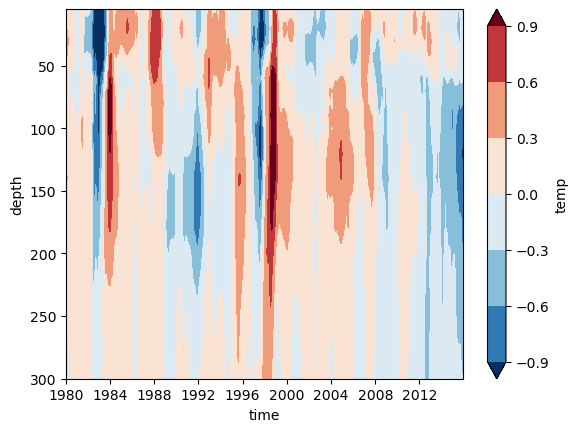

In [45]:
(anomalies(SST_off).mean(dim=('lon','lat')).temp - anomalies(SST_in).mean(dim=('lon','lat')).temp).plot.contourf(x='time',robust=True)
plt.gca().invert_yaxis()

In [53]:
SST_off.sel(depth=slice(None,50)).depth

<xarray.DataArray 'depth' (depth: 6)> Size: 48B
array([ 5, 10, 20, 30, 40, 50])
Coordinates:
  * depth    (depth) int64 48B 5 10 20 30 40 50

In [62]:
depth_CUI = ((anomalies(SST_off).mean(dim=('lon','lat')).temp - 
 anomalies(SST_in).mean(dim=('lon','lat')).temp).sel(depth=slice(None,50)
                                                    ) * SST_off.sel(depth=slice(None,50)).depth).mean('depth')

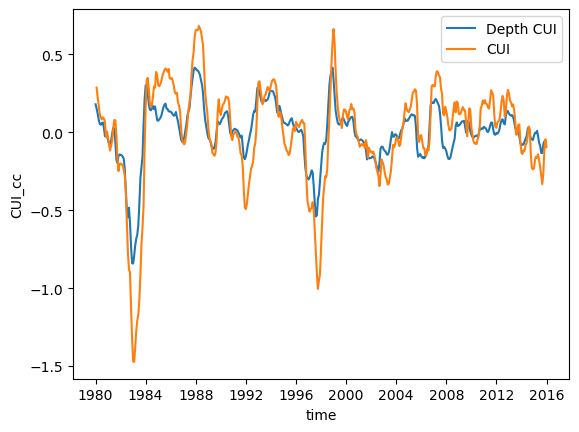

In [63]:
(depth_CUI/50).plot(label='Depth CUI')

anomalies(CUI).mean('lat').plot(label='CUI')
plt.legend()